In [3]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

import os
os.chdir("/Users/AlanHDLR/Desktop")

In [5]:
data_vw = pd.read_csv("vw.csv")
data_vw

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0
1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0
2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0
3,T-Roc,2019,33492,Automatic,4825,Petrol,145,32.5,2.0
4,T-Roc,2019,22900,Semi-Auto,6500,Petrol,150,39.8,1.5
...,...,...,...,...,...,...,...,...,...
15152,Eos,2012,5990,Manual,74000,Diesel,125,58.9,2.0
15153,Fox,2008,1799,Manual,88102,Petrol,145,46.3,1.2
15154,Fox,2009,1590,Manual,70000,Petrol,200,42.0,1.4
15155,Fox,2006,1250,Manual,82704,Petrol,150,46.3,1.2


In [7]:
data_vw["Intercepto"] = 1
data_vw = data_vw[["Intercepto", "year", "mileage", "tax", "mpg", "engineSize", "price"]]
print(data_vw.shape)
data_vw.head()

(15157, 7)


,Intercepto,year,mileage,tax,mpg,engineSize,price
0,1,2019,13904,145,49.6,2.0,25000
1,1,2019,4562,145,49.6,2.0,26883
2,1,2019,7414,145,50.4,2.0,20000
3,1,2019,4825,145,32.5,2.0,33492
4,1,2019,6500,150,39.8,1.5,22900


In [9]:
Xdata = data_vw[["Intercepto", "year", "mileage", "tax", "mpg", "engineSize"]].values
Ydata = data_vw[["price"]].values 

In [11]:
# Dividimos en base de entrenameinto y prueba 
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(Xdata, Ydata, test_size = 0.30, random_state = 1)

In [13]:
X = X_train
Y = Y_train

In [15]:
# Número de renglones en Matriz X (Base de entrenamiento)
X.shape[0]

10609

In [17]:
# Número de columnas en Matriz X (Base de entrenamiento)
X.shape[1]

6

In [19]:
# Opción de formato númerico 
np.set_printoptions(formatter = {'float_kind':'{:f}'.format})

In [21]:
# Sacara la multiplicación de X transpuesta
XT_X = np.matmul(np.matrix.transpose(X), X)
XT_X

array([[10609.000000, 21401194.000000, 233072420.000000, 1193210.000000,
        570957.800000, 16961.200000],
       [21401194.000000, 43171982552.000000, 469825148996.000000,
        2407544625.000000, 1151684648.600000, 34215355.100000],
       [233072420.000000, 469825148996.000000, 9876827808602.000000,
        21390578815.000000, 13579651181.999996, 383760914.600000],
       [1193210.000000, 2407544625.000000, 21390578815.000000,
        176634550.000000, 59476762.000000, 1996151.500000],
       [570957.800000, 1151684648.600000, 13579651181.999996,
        59476762.000000, 32738157.620000, 894313.710000],
       [16961.200000, 34215355.100000, 383760914.600000, 1996151.500000,
        894313.710000, 29370.320000]])

In [23]:
# Obtener la matriz inversa
XT_X_inv = np.linalg.inv(XT_X)
XT_X_inv

array([[234.232849, -0.116082, -0.000008, 0.000486, 0.000301, 0.026142],
       [-0.116082, 0.000058, 0.000000, -0.000000, -0.000000, -0.000013],
       [-0.000008, 0.000000, 0.000000, 0.000000, -0.000000, -0.000000],
       [0.000486, -0.000000, 0.000000, 0.000000, 0.000000, -0.000001],
       [0.000301, -0.000000, -0.000000, 0.000000, 0.000001, 0.000004],
       [0.026142, -0.000013, -0.000000, -0.000001, 0.000004, 0.000536]])

In [25]:
# Obtener la matriz transpuesta de Y
XT_Y = np.matmul(np.matrix.transpose(X), Y)
XT_Y

array([[178787650.000000],
       [360765026860.000000],
       [3030266210110.000000],
       [22654766005.000000],
       [9057032319.600000],
       [307851287.700000]])

In [27]:
betas = np.matmul(XT_X_inv, XT_Y)
betas

array([[-3014834.951091],
       [1498.128055],
       [-0.081003],
       [4.531650],
       [-75.638175],
       [9321.335395]])

In [29]:
# Calculo de TSS(Suma total de cudrados)
TSS = np.matmul(np.matrix.transpose(Y), Y) - len(Y) * (Y.mean()**2)
TSS

array([[643899084866.517090]])

In [1]:
# Calculo del ESS (Suma explicada de cuadrados)
ESS = np.matmul(np.matmul(np.matrix.transpose(betas), np.matrix.transpose(X)), np.matmul(X, betas)) - len(Y) * (Y.mean()**2)
ESS

NameError: name 'np' is not defined

In [33]:
# Calculo de RRS (Residuales al cuadrado)
RSS = TSS - ESS
RSS

array([[158226269938.795410]])

In [35]:
# Calculo de coeficiente de determinacion R Cuadrada
RSq = 1 - RSS / TSS
RSq

array([[0.754269]])

In [37]:
# Coeficiente más adecuado para regresión multiple
# Calculo del coeficiente de Determinación R Cuadrada Ajustada
RSqAj = 1 - (RSS / (X.shape[0] - X.shape[1])) / (TSS / (X.shape[0] - 1))
RSqAj

array([[0.754153]])

In [39]:
# Reporte automatizado de la rgresión en Python
import statsmodels.api as sm

regressor = sm.OLS(Y, X).fit()
print(regressor.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     6509.
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:03:16   Log-Likelihood:            -1.0267e+05
No. Observations:               10609   AIC:                         2.054e+05
Df Residuals:                   10603   BIC:                         2.054e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.015e+06   5.91e+04    -50.993      0.0

In [41]:
# Aplicación sobre la base de prueba
Y_pred = np.matmul(X_test, betas)
Y_pred

array([[15818.921422],
       [20337.998962],
       [14114.679339],
       ...,
       [13048.907617],
       [16477.740028],
       [25371.972593]])

In [43]:
# Calculo de los residuales
Resid = Y_test - Y_pred
Resid

array([[181.078578],
       [-2839.998962],
       [16884.320661],
       ...,
       [-3558.907617],
       [17.259972],
       [2617.027407]])

array([[<Axes: title={'center': '0'}>]], dtype=object)

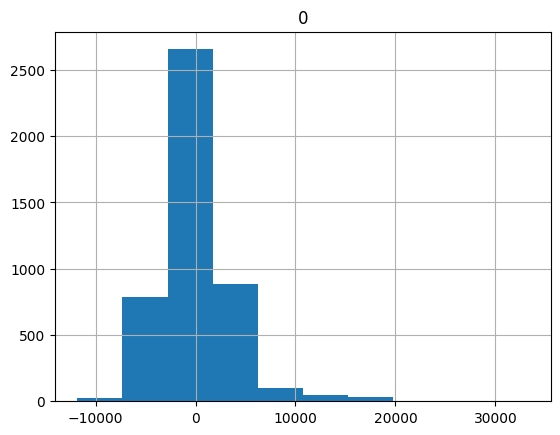

In [45]:
# Grafico del histograma de residuales para la base de prueba
df = pd.DataFrame(Resid)
df.hist()

In [47]:
from sklearn.metrics import r2_score
from sklearn import metrics

print("Cieficiente R cuadrado", r2_score(Y_test, Y_pred))

Cieficiente R cuadrado 0.7600191786722412
